<a href="https://colab.research.google.com/github/arifpras/ExpectedDemand/blob/main/20250612_potensidemand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 README

This Jupyter Notebook performs a comprehensive demand forecasting analysis using macro-financial variables. It covers data preprocessing, exploratory analysis, linear regression, diagnostic testing, machine learning modeling, and forecasting visualization.

## 🔍 Objective
To evaluate and compare predictive models for forecasting the volume of incoming bids in government bond auctions based on economic and behavioral indicators.

## 📑 Notebook Structure
The notebook is divided into modular sections:
- **Section 1**: Environment and setup
- **Section 2**: Data loading and preprocessing
- **Section 3**: Feature engineering and splitting
- **Section 4**: Linear and stepwise regression
- **Section 5**: Diagnostic tests
- **Section 6**: Machine learning models
- **Section 7**: Visualization and results
- **Section 8**: Forecasting on new data

## ⚙️ Dependencies
Key packages:
- `pandas`, `numpy`, `matplotlib`, `seaborn`
- `scikit-learn`, `statsmodels`, `tensorflow`
- `shap`, `pdfkit`, `pdfpages`

Ensure system-level packages like `wkhtmltopdf` are installed for PDF rendering.

---

# 📌 TABLE OF CONTENTS

- 📦 SECTION 1: Environment and Setup  
  - 1.1 Install and Load Packages  
  - 1.2 Import Libraries  


- 📁 SECTION 2: Data Loading and Preprocessing  
  - 2.1 Load Dataset and Define Directory  
  - 2.2 Summary Statistics and Correlation  


- 🧼 SECTION 3: Feature Engineering and Splitting  
  - 3.1 Define Features and Target  
  - 3.2 Train-Test Split and Scaling  


- 📉 SECTION 4: Linear and Stepwise Regression  
  - 4.1 Basic OLS Regression  
  - 4.2 Stepwise Variable Selection  
  - 4.3 Save OLS Summary to PDF  


- 🔍 SECTION 5: Diagnostic Tests  
  - 5.1 Multicollinearity (VIF)  
  - 5.2 Heteroskedasticity (Breusch-Pagan)  
  - 5.3 Normality (Jarque-Bera)  
  - 5.4 Autocorrelation (Durbin-Watson)  
  - 5.5 Model Specification (RESET Test)  


- 🤖 SECTION 6: Machine Learning Models  
  - 6.1 Define and Train Models  
  - 6.2 Evaluate Model Performance  
  - 6.3 Hyperparameter Tuning  
  - 6.4 Feature Importance Comparison  


- 📈 SECTION 7: Visualization and Results  
  - 7.1 Line Plot – Actual vs Predictions  
  - 7.2 Residual Plots  
  - 7.3 MSE Comparison Bar Chart  
  - 7.4 Feature Importance Chart  


- 🔮 SECTION 8: Forecasting and Interpretation  
  - 8.1 Load and Prepare New Data  
  - 8.2 Predict and Revert from Log Scale  
  - 8.3 Monthly Labeling  
  - 8.4 Stacked Bar Chart (Faceted by Model)  
  - 8.5 Summary Tables: Total and Average Predictions

---

# 📦 SECTION 1: Environment and Setup

**Purpose**: Set up all required Python packages and libraries used throughout this notebook, including machine learning, visualization, and statistical tools.

## 1.1 Install and Load Packages
Install required Python packages silently, including Scikit-learn, SHAP, Statsmodels, and system dependencies for PDF rendering.

In [1]:
%%capture
!pip install -U scikit-learn shap statsmodels
!pip install pdfkit
!apt-get update --fix-missing
!apt-get install -y wkhtmltopdf

## 1.2 Import Libraries
Import all necessary libraries for data manipulation, modeling, visualization
statistical testing, and deep learning.

In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shap
import matplotlib.ticker as ticker
import tensorflow as tf
import pdfkit

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import statsmodels.api as sm
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime
import random
import matplotlib as mpl
from scipy.stats import jarque_bera
import statsmodels.stats.api as sms
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_reset

# 📁 SECTION 2: Data Loading and Preprocessing

**Purpose**: Import and explore the dataset, define the working directory, and examine variable relationships through summary statistics and correlation plots.

## 2.1 Load Dataset and Set Working Directory
Read the dataset, define a unique working directory using a timestamp, and preview the last few rows.

In [3]:
WORKING_DIR = '/content/drive/MyDrive/00demandsbn'
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
WORKING_DIR = os.path.join(WORKING_DIR, f"run_{timestamp}")
os.makedirs(WORKING_DIR, exist_ok=True)
os.chdir(WORKING_DIR)
print(f"\U0001F4C1 Current working directory is set to:\n{WORKING_DIR}")

file_path = '/content/drive/MyDrive/00demandsbn/20250611_trainsbn.csv'
data = pd.read_csv(file_path)
print(data.tail())

📁 Current working directory is set to:
/content/drive/MyDrive/00demandsbn/run_20250618_0840
           date  auction_month  auction_year  bi_rate  spread_bifd  \
174  2025-01-01              1          2025     5.75         1.25   
175  2025-02-01              2          2025     5.75         1.25   
176  2025-03-01              3          2025     5.75         1.25   
177  2025-04-01              4          2025     5.75         1.25   
178  2025-05-01              5          2025     5.00         0.50   

     yield10_ibpa  inflation_rate  idprod_rate     jkse_avg   idrusd_avg  ...  \
174      7.133354            0.76    -1.910830  7117.449421  16261.99974  ...   
175      6.894258           -0.09     3.581636  6730.652600  16337.90050  ...   
176      6.983220            1.03    -2.594443  6457.059000  16456.15816  ...   
177      7.043499            1.95    -2.982758  6454.921375  16820.00000  ...   
178      6.879709            1.60     0.669426  7034.215353  16440.70559  ...   



## 2.2 Summary Statistics and Correlation
Generate descriptive statistics and save to CSV. Plot the correlation heatmap to understand relationships between variables.

In [4]:
columns_to_include = ['incoming_bio_log', 'dpk_bio_log', 'srbi_awardedbio_log', 'm1currency_bio_log',
                      'forh_avg', 'inpp_avg', 'move', 'yield01_ibpa', 'inflation_rate', 'idprod_rate',
                      'number_series', 'bi_covid', 'long_holiday', 'auction_month']
data_filtered_ds = data[columns_to_include]

summary_stats = data_filtered_ds.describe().transpose()[['count', 'mean', 'std', 'min', 'max']]
summary_stats.to_csv(f"{timestamp}_summary_stats.csv")
print("Summary stats saved.")

Summary stats saved.


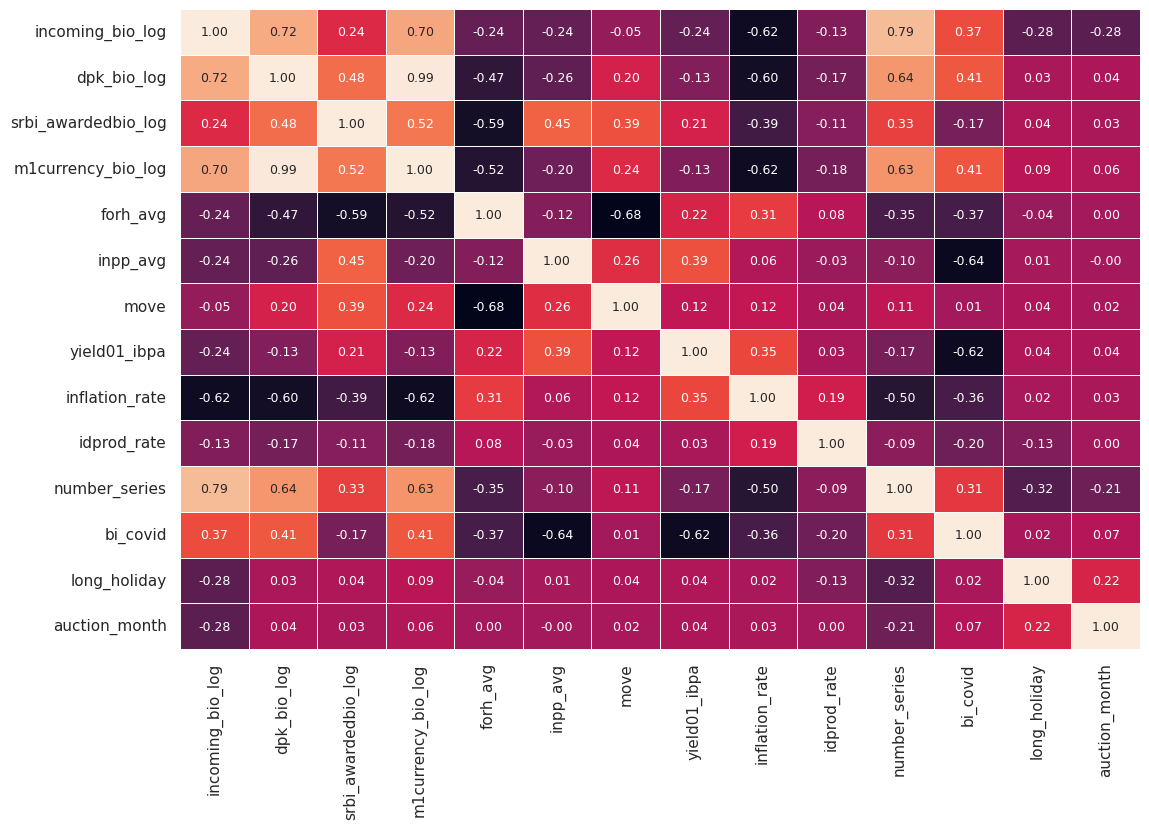

In [5]:
sns.set_theme()
f, ax = plt.subplots(figsize=(12, 8))
heatmap = sns.heatmap(data_filtered_ds.corr(), annot=True, fmt=".2f", linewidths=.5, ax=ax,
                      annot_kws={"size": 9}, cbar=False)
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
plt.savefig(f"{timestamp}_heatmap.pdf", format='pdf', bbox_inches='tight')
plt.show()

# 🧼 SECTION 3: Feature Engineering and Splitting

**Purpose**: Define the feature set and target variable. Split the data into training and testing sets, and apply standard scaling to normalize the input features.

## 3.1 Define Features and Target
Select the predictor variables (`X`) and define the target variable (`y`) for supervised learning.

In [6]:
feature_columns = ['dpk_bio_log', 'srbi_awardedbio_log', 'm1currency_bio_log', 'forh_avg', 'inpp_avg',
                   'move', 'yield01_ibpa', 'inflation_rate', 'idprod_rate', 'number_series', 'bi_covid',
                   'long_holiday', 'auction_month']
target_column = 'incoming_bio_log'

X = data[feature_columns]
y = data[target_column]

## 3.2 Split Data and Scale
Perform train-test split and apply standard scaling to ensure numerical stability across models.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=feature_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=feature_columns)

# 📉 SECTION 4: Linear and Stepwise Regression

**Purpose**: Perform baseline linear regression and stepwise regression to identify statistically significant predictors. Save regression output for documentation.

## 4.1 Basic OLS
Fit an ordinary least squares regression model using the full feature set and display robust standard errors.

In [8]:
model = sm.OLS(y_train, sm.add_constant(X_train_scaled)).fit(cov_type='HC0')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       incoming_bio_log   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     37.04
Date:                Wed, 18 Jun 2025   Prob (F-statistic):           3.21e-37
Time:                        08:42:47   Log-Likelihood:                 59.897
No. Observations:                 143   AIC:                            -91.79
Df Residuals:                     129   BIC:                            -50.31
Df Model:                          13                                         
Covariance Type:                  HC0                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   4.8929    

## 4.2 Save OLS Output to PDF
Convert OLS regression summary into a PDF format for reporting and archiving.

In [9]:
summary_text = model.summary().as_text()
filename = f"{timestamp}_ols.pdf"
with PdfPages(filename) as pdf:
    plt.figure(figsize=(12, 8))
    plt.text(0.1, 0.9, summary_text, {'fontsize': 9}, fontproperties='monospace', wrap=True)
    plt.axis('off')
    plt.subplots_adjust(left=0.1, right=0.2, top=0.2, bottom=0.1)
    pdf.savefig()
    plt.close()

## 4.3 Stepwise Selection
Use stepwise forward and backward selection to find a parsimonious set of statistically significant variables.

In [10]:
def stepwise_selection(X, y, threshold_in=0.09, threshold_out=0.09):
    included = []
    while True:
        changed = False
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded)
        for col in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [col]])).fit()
            new_pval[col] = model.pvalues[col]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
        model = sm.OLS(y, sm.add_constant(X[included])).fit()
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max()
        if worst_pval > threshold_out:
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            changed = True
        if not changed:
            break
    return included

In [11]:
# Generate the current date and time in the desired format
# current_time = datetime.now()
# formatted_time = current_time.strftime("%Y%m%d_%H%M")

# Define the filename
filename = f"{timestamp}_stepwise.pdf"

# Ensure feature_columns matches the features in X_train
feature_columns = list(X_train.columns)  # Use the original feature names

# Convert scaled data back to DataFrame with correct indices and columns
X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=feature_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=feature_columns)

# Stepwise Regression
resulting_features = stepwise_selection(X_train_scaled, y_train)

# Define and fit the model
stepwise_model = sm.OLS(y_train, sm.add_constant(X_train_scaled[resulting_features]))
stepwise_fit = stepwise_model.fit(cov_type='HC0')

# Print and export summary
print(stepwise_fit.summary())
summary_text_stepwise = stepwise_fit.summary().as_text()

# Save summary text to a PDF
with PdfPages(filename) as pdf:
    # Create a new figure
    plt.figure(figsize=(12, 8))
    plt.text(0.01, 0.05, summary_text_stepwise, {'fontsize': 9}, fontproperties='monospace')
    plt.axis('off')
    plt.subplots_adjust(left=0.1, right=0.2, top=0.2, bottom=0.1)  # Fine-tune margins
    pdf.savefig()  # Save the current figure
    plt.close()

                            OLS Regression Results                            
Dep. Variable:       incoming_bio_log   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     60.27
Date:                Wed, 18 Jun 2025   Prob (F-statistic):           1.74e-38
Time:                        08:43:00   Log-Likelihood:                 58.469
No. Observations:                 143   AIC:                            -100.9
Df Residuals:                     135   BIC:                            -77.23
Df Model:                           7                                         
Covariance Type:                  HC0                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   4.8929    

# 🔍 SECTION 5: Diagnostic Tests

**Purpose**: Evaluate assumptions of the linear regression model through diagnostic tests such as multicollinearity (VIF), heteroskedasticity (BP), residual normality (JB), autocorrelation (DW), and functional form misspecification (RESET).

## 5.1 Multicollinearity (VIF)
**Interpretation**: VIF (Variance Inflation Factor) measures how much the variance of a regression coefficient is inflated due to multicollinearity with other variables.

- **VIF = 1**: No multicollinearity
- **1 < VIF < 5**: Acceptable levels
- **5 < VIF < 10**: Caution—moderate multicollinearity
- **VIF > 10**: Strong multicollinearity—consider removing or combining variables

A high VIF suggests the variable is highly correlated with others and can destabilize model coefficients, making interpretations less reliable.

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X_train_scaled[resulting_features])
vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif)

              Variable       VIF
0                const  1.000000
1        number_series  2.361431
2          dpk_bio_log  2.689553
3                 move  1.393363
4        auction_month  1.155194
5         long_holiday  1.275528
6       inflation_rate  1.925830
7  srbi_awardedbio_log  1.675006


## 5.2 Heteroskedasticity (Breusch-Pagan)
**Interpretation**: The Breusch-Pagan test checks whether the variance of residuals is constant (homoskedasticity).

- **Null hypothesis**: Residuals have constant variance (no heteroskedasticity)
- **Low p-value (< 0.05)**: Reject null → heteroskedasticity likely present
- **High p-value**: Fail to reject null → variance is constant

Heteroskedasticity may lead to inefficient estimates and biased standard errors. Consider using robust standard errors if present.
Apply Breusch-Pagan test to check if residual variance depends on the regressors.

In [13]:
import statsmodels.stats.api as sms

bp_test = sms.het_breuschpagan(stepwise_fit.resid, stepwise_fit.model.exog)
bp_test_results = dict(zip(['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value'], bp_test))

print(bp_test_results)

{'Lagrange multiplier statistic': np.float64(10.220940169533712), 'p-value': np.float64(0.1763949061574346), 'f-value': np.float64(1.4845573699097563), 'f p-value': np.float64(0.1778123477839462)}


## 5.3 Normality (Jarque-Bera)
**Interpretation**: The Jarque-Bera test evaluates whether the residuals are normally distributed.

- **Null hypothesis**: Residuals are normally distributed
- **Low p-value (< 0.05)**: Reject null → residuals are not normal
- **High p-value**: Fail to reject null → residuals appear normal

Normality of residuals matters for inference (e.g., confidence intervals, p-values). Non-normality may require data transformation or bootstrapping.
Evaluate normality of residuals using Jarque-Bera test—an assumption for inference validity.

In [14]:
from scipy.stats import jarque_bera

jb_test = jarque_bera(stepwise_fit.resid)
jb_test_results = dict(zip(['JB statistic', 'p-value', 'skew', 'kurtosis'], jb_test))

print(jb_test_results)

{'JB statistic': np.float64(1.0717222546794336), 'p-value': np.float64(0.5851651713933893)}


## 5.4 Autocorrelation (Durbin-Watson)

**Interpretation**: The Durbin-Watson statistic detects autocorrelation in the residuals (especially in time-series data).

- **DW ≈ 2**: No autocorrelation
- **DW < 2**: Positive autocorrelation
- **DW > 2**: Negative autocorrelation

Autocorrelation may indicate model misspecification. Consider adding lag variables or switching to time-series models like ARIMA. Check for autocorrelation in residuals. DW ≈ 2 indicates no autocorrelation.

In [15]:
from statsmodels.stats.stattools import durbin_watson

dw_statistic = durbin_watson(stepwise_fit.resid)

print(f'Durbin-Watson statistic: {dw_statistic:.4f}')

Durbin-Watson statistic: 1.8693


## 5.5 Model Specification (Ramsey RESET)

**Interpretation**: The RESET test checks whether the linear regression model is correctly specified.

- **Null hypothesis**: Model is correctly specified
- **Low p-value (< 0.05)**: Reject null → model may be mis-specified
- **High p-value**: Fail to reject null → no strong evidence of mis-specification

Mis-specification could stem from omitted variables or incorrect functional form. Consider adding interaction terms or nonlinear transformations. Test the correctness of the functional form. A high p-value means no strong evidence of misspecification.

In [16]:
from statsmodels.stats.diagnostic import linear_reset

reset_test = linear_reset(stepwise_fit, power=2, use_f=True)

print(f"RESET test F-statistic: {reset_test.fvalue:.4f}, p-value: {reset_test.pvalue:.4f}")

RESET test F-statistic: 1.0096, p-value: 0.3168


# 🤖 SECTION 6: Machine Learning Models

**Purpose**: Train multiple machine learning models—including tree-based methods, linear regression, and deep learning—on the dataset. Evaluate their prediction performance using R-squared and MSE.

## 6.1 Define & Train Models
Define baseline regressors including tree ensembles, linear regression, and a neural network.

In [17]:
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    # "Linear Regression": LinearRegression(),
    "Deep Learning": Sequential([
        Dense(128, input_dim=X_train_scaled.shape[1], activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
}

models["Deep Learning"].compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 6.2 Evaluate Models
Fit each model, predict on test data, and store Mean Squared Error and R-squared metrics.
Also includes predictions from the final stepwise OLS model for comparison.

In [18]:
# Early stopping callback for Deep Learning
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train and evaluate models
results = {}
r2_scores = {}
predictions_df = pd.DataFrame({'Actual': y_test.values}, index=y_test.index)

# Convert scaled data back to DataFrame with correct indices and columns
feature_columns = list(X_train.columns)  # Use the original feature names
X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=feature_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=feature_columns)

# Train and evaluate Scikit-learn models and Deep Learning model
for model_name, model in models.items():
    if model_name == "Deep Learning":
        # Train the Deep Learning model
        model.fit(
            X_train_scaled, y_train,
            validation_split=0.2, epochs=200, batch_size=32,
            callbacks=[early_stopping], verbose=0
        )
        y_pred = model.predict(X_test_scaled).flatten()
    else:
        # Train Scikit-learn models
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled).flatten()

    # Calculate performance metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[model_name] = mse
    r2_scores[model_name] = r2
    predictions_df[model_name] = y_pred

# Stepwise Regression
resulting_features = stepwise_selection(X_train_scaled, y_train)

# Handle Stepwise Regression separately
stepwise_model = sm.OLS(y_train, sm.add_constant(X_train_scaled[resulting_features]))
stepwise_fit = stepwise_model.fit(cov_type='HC0')

# Ensure the constant column is added only once
X_test_stepwise = sm.add_constant(X_test_scaled[resulting_features], has_constant='add')
y_pred_stepwise = stepwise_fit.predict(X_test_stepwise)

# Calculate performance metrics for Stepwise Regression
mse_stepwise = mean_squared_error(y_test, y_pred_stepwise)
r2_stepwise = r2_score(y_test, y_pred_stepwise)
results["Stepwise Regression"] = mse_stepwise
r2_scores["Stepwise Regression"] = r2_stepwise
predictions_df["Stepwise Regression"] = y_pred_stepwise

# Sort the models from highest R-squared to lowest
sorted_results = sorted(results.items(), key=lambda x: r2_scores[x[0]], reverse=True)

# Display sorted results
for model_name, mse in sorted_results:
    print(f"{model_name}: MSE = {mse:.4f}, R-squared = {r2_scores[model_name]:.4f}")

# Find the best model based on Mean Squared Error
best_model_name = min(results, key=results.get)
best_model_mse = results[best_model_name]
best_model_r2 = r2_scores[best_model_name]

print(f"\nThe best model is {best_model_name} with MSE = {best_model_mse:.4f} and R-squared = {best_model_r2:.4f}.")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Stepwise Regression: MSE = 0.0194, R-squared = 0.8350
Gradient Boosting: MSE = 0.0204, R-squared = 0.8267
Random Forest: MSE = 0.0245, R-squared = 0.7922
AdaBoost: MSE = 0.0281, R-squared = 0.7613
Deep Learning: MSE = 0.3852, R-squared = -2.2706

The best model is Stepwise Regression with MSE = 0.0194 and R-squared = 0.8350.


## 6.3 Tune Hyperparameters
Perform grid search cross-validation on selected models (e.g., Random Forest, AdaBoost) to optimize parameters.

In [19]:
# 📌 Set random seed for reproducibility
random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)
random.seed(random_seed)

# 🎛️ Define parameter grids
param_grids = {
    "Random Forest": {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    "AdaBoost": {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.1, 1.0]
    },
    "Gradient Boosting": {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0]
    }
}

# ⚙️ Initialize models
models = {
    "Random Forest": RandomForestRegressor(random_state=random_seed),
    "AdaBoost": AdaBoostRegressor(random_state=random_seed),
    "Gradient Boosting": GradientBoostingRegressor(random_state=random_seed)
}

## 6.4 Standard Models

In [57]:
# 📊 Initialize result containers
tuned_models = {}
results = {}
r2_scores = {}
predictions_df = pd.DataFrame({'Actual': y_test.values}, index=y_test.index)

# 🔍 Perform grid search and evaluation
for model_name, model in models.items():
    print(f"\n🔧 Tuning {model_name}...")
    if model_name in param_grids:
        grid_search = GridSearchCV(model, param_grids[model_name], cv=5,
                                   scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)
        grid_search.fit(X_train_scaled, y_train)
        best_model = grid_search.best_estimator_
        tuned_models[model_name] = best_model
        print(f"✅ Best params for {model_name}: {grid_search.best_params_}")
    else:
        best_model = model
        tuned_models[model_name] = best_model

    # Evaluate on test set
    y_pred = best_model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[model_name] = mse
    r2_scores[model_name] = r2
    predictions_df[model_name] = y_pred



🔧 Tuning Random Forest...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
✅ Best params for Random Forest: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

🔧 Tuning AdaBoost...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
✅ Best params for AdaBoost: {'learning_rate': 1.0, 'n_estimators': 50}

🔧 Tuning Gradient Boosting...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
✅ Best params for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


## 6.4 Deep Learning Architecture
Build, compile, and train a more complex neural network with dropout and L2 regularization.

In [58]:
%%capture

dl_model = Sequential([
    Dense(256, input_dim=X_train_scaled.shape[1], activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1)
])

dl_model.compile(optimizer=Adam(0.001), loss='mean_squared_error')
dl_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2, epochs=300, batch_size=64,
    callbacks=[EarlyStopping(patience=20, restore_best_weights=True)],
    verbose=1
)

y_pred_dl = dl_model.predict(X_test_scaled).flatten()
results["Deep Learning"] = mean_squared_error(y_test, y_pred_dl)
r2_scores["Deep Learning"] = r2_score(y_test, y_pred_dl)
predictions_df["Deep Learning"] = y_pred_dl

## 6.5 Stepwise Regression

In [59]:
# Stepwise Regression
resulting_features = stepwise_selection(X_train_scaled, y_train)

# Handle Stepwise Regression separately
stepwise_model = sm.OLS(y_train, sm.add_constant(X_train_scaled[resulting_features]))
stepwise_fit = stepwise_model.fit(cov_type='HC0')
# print(stepwise_fit.summary())

# Ensure the constant column is added only once
X_test_stepwise = sm.add_constant(X_test_scaled[resulting_features], has_constant='add')
y_pred_stepwise = stepwise_fit.predict(X_test_stepwise)

# Calculate performance metrics for Stepwise Regression
mse_stepwise = mean_squared_error(y_test, y_pred_stepwise)
r2_stepwise = r2_score(y_test, y_pred_stepwise)
results["Stepwise Regression"] = mse_stepwise
r2_scores["Stepwise Regression"] = r2_stepwise
predictions_df["Stepwise Regression"] = y_pred_stepwise

In [60]:
# Sort the models from highest R-squared to lowest
sorted_results = sorted(results.items(), key=lambda x: r2_scores[x[0]], reverse=True)

# Display sorted results
for model_name, mse in sorted_results:
    print(f"{model_name}: MSE = {mse:.4f}, R-squared = {r2_scores[model_name]:.4f}")

# Find the best model based on Mean Squared Error
best_model_name = min(results, key=results.get)
best_model_mse = results[best_model_name]
best_model_r2 = r2_scores[best_model_name]

print(f"\nThe best model is {best_model_name} with MSE = {best_model_mse:.4f} and R-squared = {best_model_r2:.4f}.")

Stepwise Regression: MSE = 0.0194, R-squared = 0.8350
Gradient Boosting: MSE = 0.0222, R-squared = 0.8118
Random Forest: MSE = 0.0237, R-squared = 0.7988
AdaBoost: MSE = 0.0281, R-squared = 0.7613
Deep Learning: MSE = 0.1268, R-squared = -0.0770

The best model is Stepwise Regression with MSE = 0.0194 and R-squared = 0.8350.


In [61]:
# ✅ Skip intercept and get coefficients
coef = stepwise_fit.params[1:]

# 🧮 Normalize importance
stepwise_importance = abs(coef) / abs(coef).sum()

# ✅ Sort by importance
sorted_indices = np.argsort(stepwise_importance.values)[::-1]  # use .values for numpy ops
sorted_features = [(coef.index[i], stepwise_importance.iloc[i]) for i in sorted_indices]

# 🏷️ Print sorted features
print("🧮 Features sorted by Stepwise Regression importance (most to least):")
for name, importance in sorted_features:
    print(f"{name}: {importance:.4f}")

# ➕/- Relationship based on coefficient sign
relationships = ["positive" if coef.iloc[i] > 0 else "negative" for i in sorted_indices]

print("\n📉 Relationship with target (from Stepwise Regression):")
for name, relation in zip([coef.index[i] for i in sorted_indices], relationships):
    print(f"{name}: {relation}")


🧮 Features sorted by Stepwise Regression importance (most to least):
dpk_bio_log: 0.3213
number_series: 0.2319
auction_month: 0.1191
inflation_rate: 0.1045
srbi_awardedbio_log: 0.0774
move: 0.0773
long_holiday: 0.0685

📉 Relationship with target (from Stepwise Regression):
dpk_bio_log: positive
number_series: positive
auction_month: negative
inflation_rate: negative
srbi_awardedbio_log: negative
move: negative
long_holiday: negative


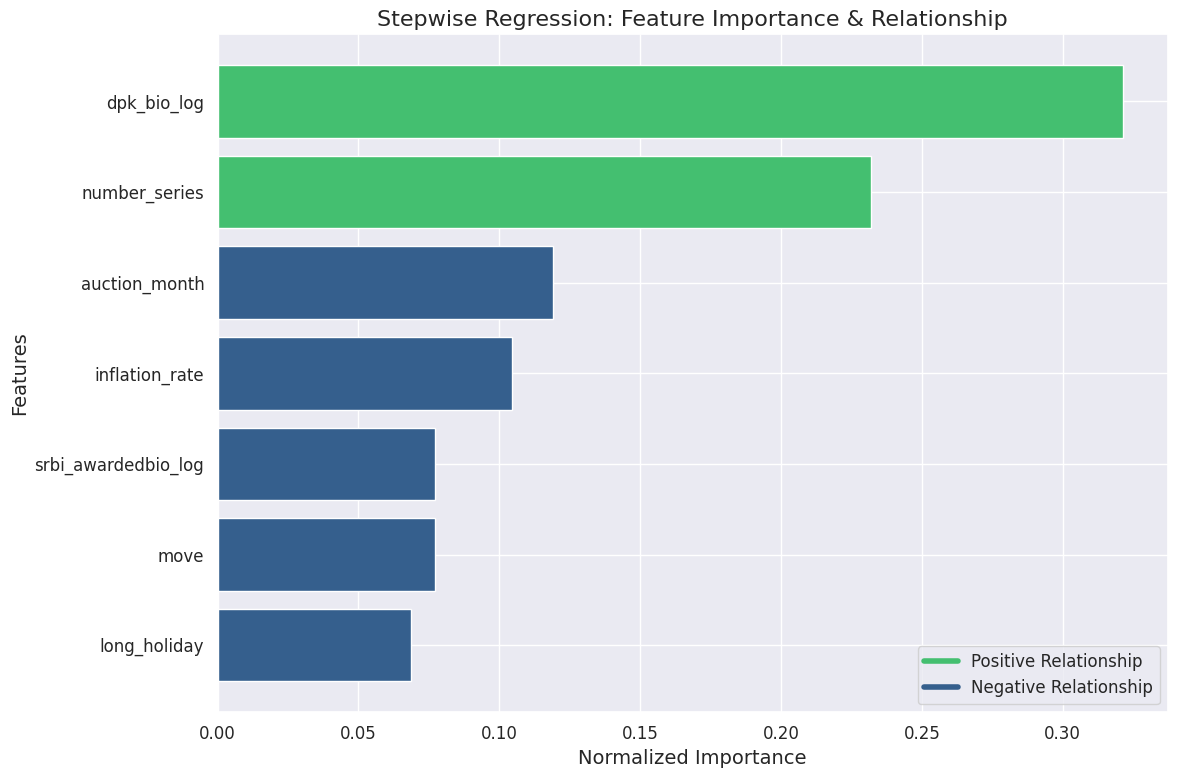

✅ The plot has been saved to: 20250618_0904_feature.pdf


In [62]:
from matplotlib.backends.backend_pdf import PdfPages

# 🕒 Timestamped filename
current_time = datetime.now()
formatted_time = current_time.strftime("%Y%m%d_%H%M")
filename = f"{formatted_time}_feature.pdf"

# 🎨 Reset style and apply consistent theme
plt.rcdefaults()
sns.set_theme(context='notebook', style='darkgrid')

# ✏️ Font size adjustments
plt.rc('font', size=14)
plt.rc('axes', titlesize=16)
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
plt.rc('legend', fontsize=12)
plt.rc('figure', titlesize=18)

# 🖼️ Plot configuration
fig, ax = plt.subplots(figsize=(12, 8))

# ✅ Use consistent color palette
cmap = plt.colormaps['viridis']
colors = [cmap(0.7) if rel == 'positive' else cmap(0.3) for rel in relationships]

# 📊 Horizontal bar chart
bars = ax.barh(range(len(feature_names)), feature_importance, color=colors, align='center')
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels(feature_names)
ax.invert_yaxis()  # Most important feature at the top
ax.set_xlabel('Normalized Importance')
ax.set_ylabel('Features')
ax.set_title('Stepwise Regression: Feature Importance & Relationship')

# 🧩 Add color legend
positive_patch = plt.Line2D([0], [0], color=cmap(0.7), lw=4, label='Positive Relationship')
negative_patch = plt.Line2D([0], [0], color=cmap(0.3), lw=4, label='Negative Relationship')
ax.legend(handles=[positive_patch, negative_patch], loc='lower right')

# 📐 Adjust margins
plt.tight_layout()

# 💾 Save to PDF and show plot
with PdfPages(filename) as pdf:
    pdf.savefig(fig)

plt.show()
print(f"✅ The plot has been saved to: {filename}")

# 📈 SECTION 7: Visualization and Results

**Purpose**: Visualize model performance through line plots, residual distributions, and MSE comparisons to understand how well each model replicates the actual values.

## 7.1 Line Plot - Actual vs Predictions
Visualize the model outputs compared to the actual test set values using line plots.

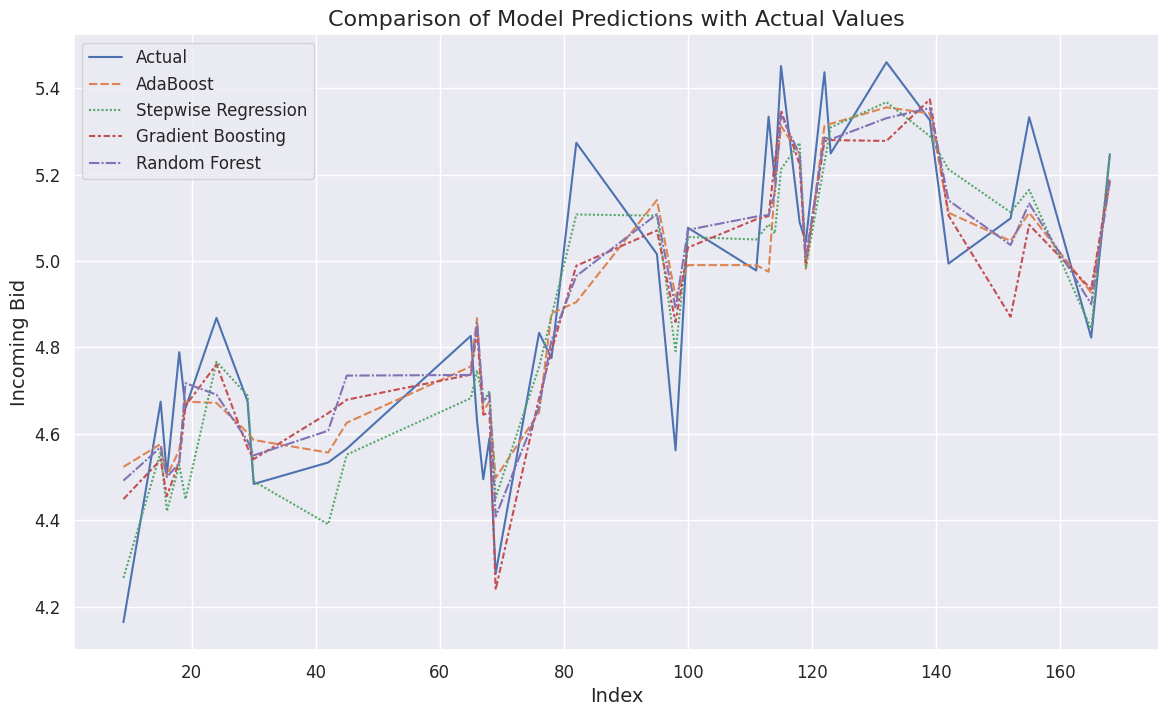

In [63]:
plt.figure(figsize=(14, 8))
sns.lineplot(data=predictions_df[['Actual', 'AdaBoost', 'Stepwise Regression', 'Gradient Boosting', 'Random Forest']])
plt.title('Comparison of Model Predictions with Actual Values')
plt.xlabel('Index')
plt.ylabel('Incoming Bid')
plt.legend(loc='upper left')
plt.show()

In [65]:
# 🔁 Create a copy before modifying
predictions_df_log = predictions_df.copy()

# 🔄 Revert log-scale to original scale
columns_to_revert = ['Actual', 'AdaBoost', 'Stepwise Regression', 'Gradient Boosting', 'Random Forest']
predictions_df_log[columns_to_revert] = predictions_df_log[columns_to_revert].apply(lambda x: 10 ** x)

# 🔎 Optional preview
print(predictions_df_log[columns_to_revert].head())

# 💾 Export
predictions_df_log.to_csv("predictions_df.csv", index=False)

            Actual       AdaBoost  Stepwise Regression  Gradient Boosting  \
78    59607.200044   75672.750990         74582.312411       61999.810373   
16    32008.400025   31821.785524         26345.743138       28544.570458   
65    67080.999975   57003.551136         48125.764712       54566.474221   
114  153812.299880  147728.655770        115803.576956      169520.234763   
76    68210.000074   44630.941367         56868.156057       48154.517219   

     Random Forest  
78    65576.863706  
16    31596.832286  
65    54470.936252  
114  143313.972120  
76    45854.550496  


## 7.2 Residual Analysis
Plot residuals vs. actuals for each model to inspect patterns or biases in predictions.

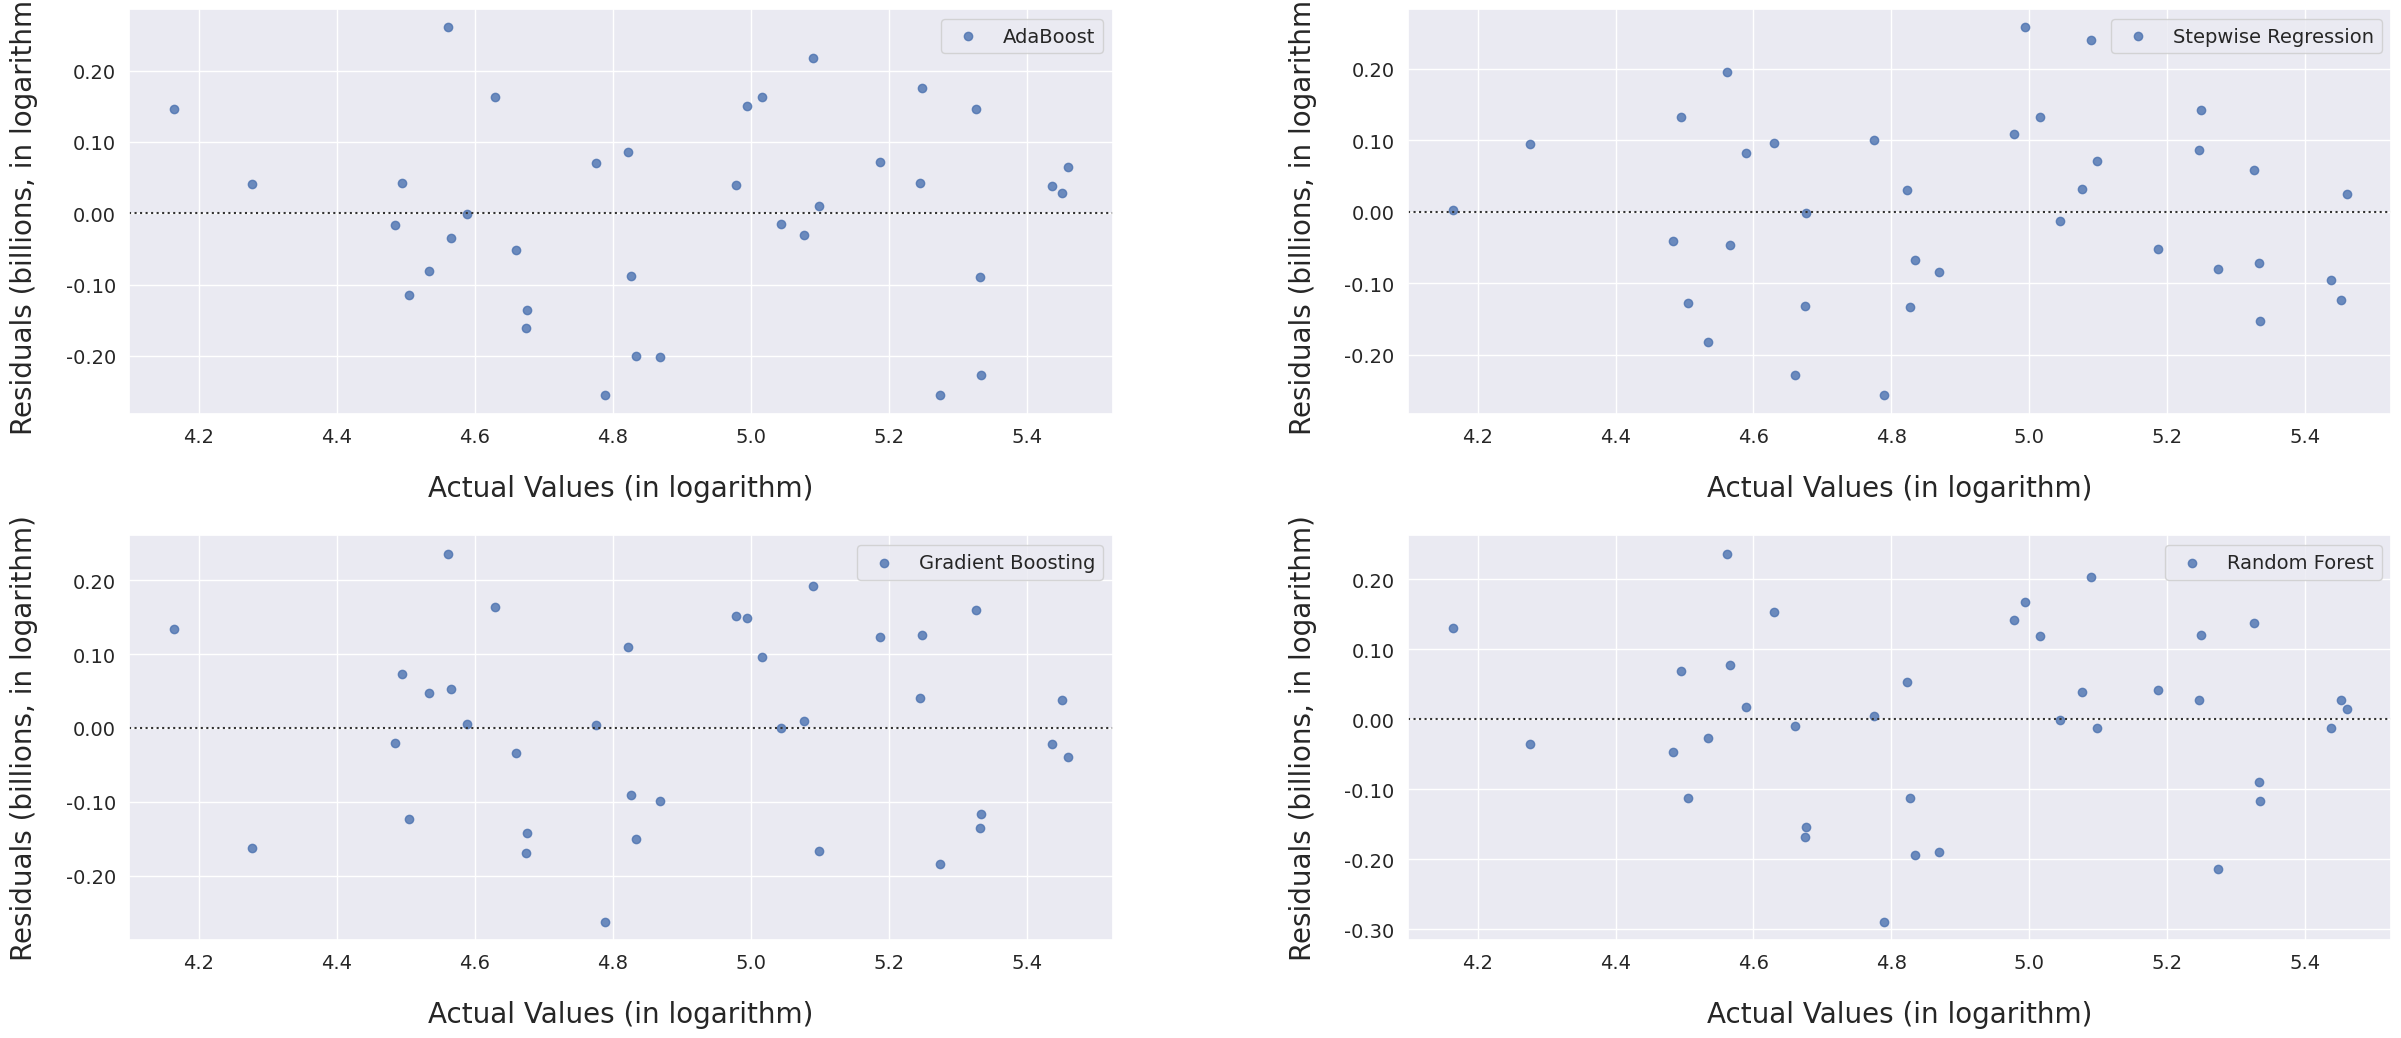

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(29.19, 12.09))
model_names = ['AdaBoost', 'Stepwise Regression', 'Gradient Boosting', 'Random Forest']
for ax, model_name in zip(axes.flatten(), model_names):
    sns.residplot(x=predictions_df['Actual'], y=predictions_df[model_name], ax=ax, label=model_name)
    ax.set_xlabel('Actual Values (in logarithm)', fontsize=20, labelpad=20)
    ax.set_ylabel('Residuals (billions, in logarithm)', fontsize=20, labelpad=20)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.2f}'))
    ax.legend(fontsize=14)
plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

# 7.3 MSE Bar Chart
Compare model performance visually by plotting Mean Squared Errors in a horizontal bar chart.

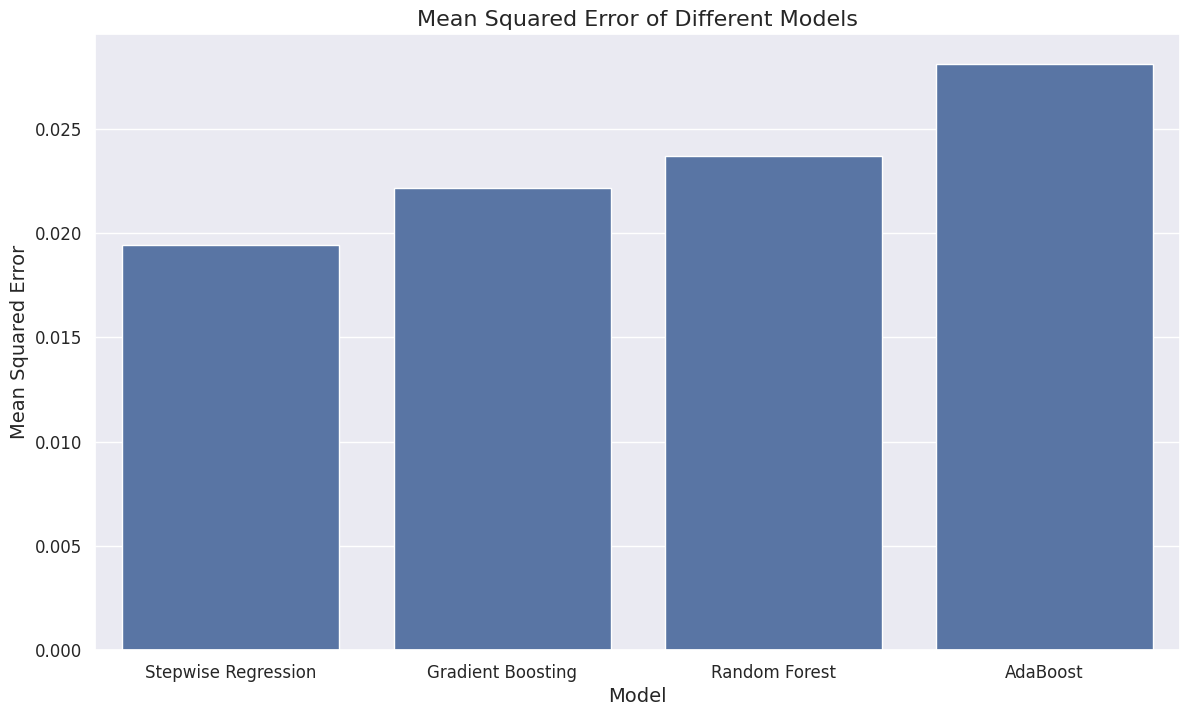

In [71]:
results_selected = ['AdaBoost', 'Stepwise Regression', 'Gradient Boosting', 'Random Forest']
filtered_results = {model: results[model] for model in results_selected}
sorted_filtered_results = sorted(filtered_results.items(), key=lambda x: x[1])
sorted_model_names = [item[0] for item in sorted_filtered_results]
sorted_mse_values = [item[1] for item in sorted_filtered_results]
plt.figure(figsize=(14, 8))
sns.barplot(x=sorted_model_names, y=sorted_mse_values)
plt.title('Mean Squared Error of Different Models')
plt.xlabel('Model')
plt.ylabel('Mean Squared Error')
plt.show()

# 🔮 SECTION 8: Forecasting on New Data

**Purpose**: Apply trained models to unseen data for forecasting. Visualize monthly predictions and provide aggregated insights such as model totals and average performance over the forecast horizon.

## 8.1 Predict New Period
Use the trained models to generate predictions on new unseen datasets for upcoming periods.

In [72]:
# 📥 Load new data for prediction
file_path_nd = '/content/drive/MyDrive/00demandsbn/20250611_predictsbn.csv'
new_data = pd.read_csv(file_path_nd)

# 🎯 Scale using the existing training scaler
new_data_scaled = scaler.transform(new_data[feature_columns])
new_data_scaled_df = pd.DataFrame(new_data_scaled, columns=feature_columns)

# 🔮 Predict using tuned models
predictions = {}
for model_name, model in tuned_models.items():
    predictions[model_name] = model.predict(new_data_scaled_df)

# 🧠 Predict using Stepwise Regression model
# Ensure that stepwise_fit and resulting_features are already defined from training phase
new_data_stepwise = sm.add_constant(new_data_scaled_df[resulting_features], has_constant='add')
predictions["Stepwise Regression"] = stepwise_fit.predict(new_data_stepwise)

# 🧾 Combine predictions with original data
comparison_df = new_data.copy()
for model_name, preds in predictions.items():
    comparison_df[model_name] = preds

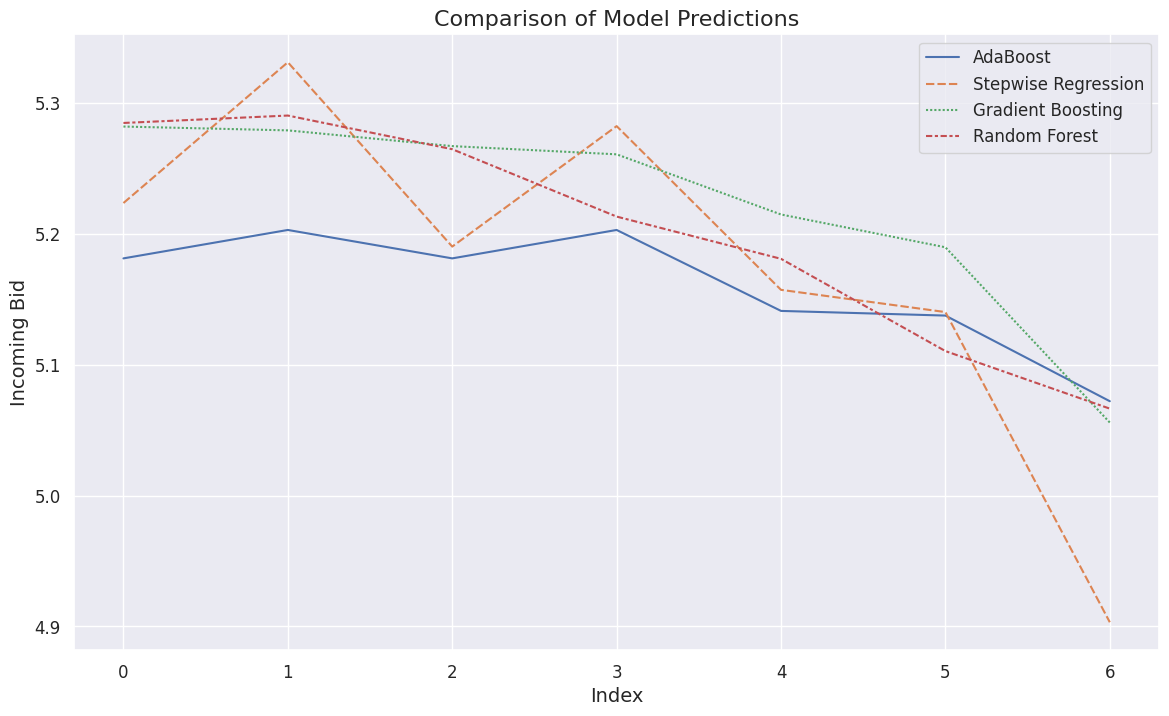

In [73]:
# Visualize the comparison using seaborn
plt.figure(figsize=(14, 8))
sns.lineplot(data=comparison_df[['AdaBoost', 'Stepwise Regression', 'Gradient Boosting', 'Random Forest']])
plt.title('Comparison of Model Predictions')
plt.xlabel('Index')
plt.ylabel('Incoming Bid')
plt.legend(loc='upper right')
plt.show()

In [74]:
comparison_df

,date,auction_month,auction_year,bi_rate,spread_bifd,yield10_ibpa,inflation_rate,idprod_rate,jkse_avg,idrusd_avg,...,srbi_awardedbio_log,srbi_bid_to_cover,srbi_way_incoming,srbi_way_awarded,yield01_ibpa,yield05_ibpa,Random Forest,AdaBoost,Gradient Boosting,Stepwise Regression
0,2025-06-01,6,2025,5,0.5,7.260590,1.602000,-3.504802,7666.315243,16520.36642,...,4.886543,1.329551,6.466756,6.441436,6.188373,6.544427,5.284614,5.181166,5.281878,5.223451
1,2025-07-01,7,2025,5,0.5,6.837182,1.581436,-2.679419,7891.921180,16561.23636,...,4.905093,1.330879,6.492653,6.467227,6.185678,6.541011,5.290273,5.202877,5.278949,5.330990
2,2025-08-01,8,2025,5,0.5,6.299181,1.560823,-0.469538,7910.906629,16602.06877,...,4.924033,1.332243,6.519036,6.493504,6.183105,6.536649,5.264556,5.181166,5.266928,5.190172
3,2025-09-01,9,2025,5,0.5,6.153419,1.540279,0.838487,8262.452504,16642.86482,...,4.943350,1.333639,6.545890,6.520249,6.180650,6.532190,5.213097,5.202877,5.260652,5.282200
4,2025-10-01,10,2025,5,0.5,6.029665,1.511100,-2.448388,8456.874417,16683.62562,...,4.963033,1.335068,6.573200,6.547448,6.178310,6.527741,5.180828,5.141038,5.214703,5.157129
5,2025-11-01,11,2025,5,0.5,5.960152,1.488570,-2.327535,8567.144105,16724.35228,...,4.983069,1.336528,6.600951,6.575087,6.176080,6.523302,5.110349,5.137476,5.189639,5.140154
6,2025-12-01,12,2025,5,0.5,5.890535,1.465985,0.514951,8586.732016,16765.04583,...,5.003449,1.338019,6.629130,6.603152,6.173959,6.518872,5.066383,5.072058,5.055763,4.903209


## 8.2 Revert from Log
Transform model outputs from log-scale back to real (decimal) scale for interpretability.

In [75]:
# 📊 Columns to revert from log-scale
columns_to_revert = ['AdaBoost', 'Stepwise Regression', 'Gradient Boosting',
                     'Random Forest']

# 🔄 Apply inverse log10 transformation (from log10 scale to real scale)
comparison_df[columns_to_revert] = comparison_df[columns_to_revert].apply(lambda x: 10 ** x)

# 🔎 Preview
print(comparison_df[columns_to_revert].head())

        AdaBoost  Stepwise Regression  Gradient Boosting  Random Forest
0  151763.091962        167282.835343      191371.903437  192581.116991
1  159542.666826        214284.014444      190085.510318  195107.023332
2  151763.091962        154943.127635      184896.070785  183889.042165
3  159542.666826        191513.743896      182243.674908  163341.639319
4  138368.882959        143591.466033      163946.634861  151644.795774


## 8.3 Add Month Labels
Append calendar month labels to each prediction to prepare for time-based aggregation.

In [76]:
# 🗓️ Generate calendar month labels
months = pd.date_range(start='2025-06-01', periods=len(comparison_df), freq='M').strftime('%b %Y')
comparison_df['Month'] = months

# 🔎 Preview
print(comparison_df[['Month'] + columns_to_revert])

      Month       AdaBoost  Stepwise Regression  Gradient Boosting  \
0  Jun 2025  151763.091962        167282.835343      191371.903437   
1  Jul 2025  159542.666826        214284.014444      190085.510318   
2  Aug 2025  151763.091962        154943.127635      184896.070785   
3  Sep 2025  159542.666826        191513.743896      182243.674908   
4  Oct 2025  138368.882959        143591.466033      163946.634861   
5  Nov 2025  137238.423155        138087.427112      154753.062153   
6  Dec 2025  118047.910743         80021.922892      113700.603227   

   Random Forest  
0  192581.116991  
1  195107.023332  
2  183889.042165  
3  163341.639319  
4  151644.795774  
5  128928.484080  
6  116515.230470  


## 8.4 Stacked Plot & Monthly Summary
Generate stacked bar charts of monthly predictions and compute the total and average for each model.

In [77]:
# 🗓 Ensure month ordering
month_order = pd.date_range(start='2025-06-01', periods=len(comparison_df), freq='M').strftime('%b %Y')
comparison_df['Month'] = pd.Categorical(comparison_df['Month'], categories=month_order, ordered=True)

In [78]:
comparison_df.to_csv("comparison_df.csv", index=False)

In [79]:
# 🔄 Melt to long-form
melted_df = comparison_df.melt(
    id_vars='Month',
    value_vars=columns_to_revert,
    var_name='Model',
    value_name='Predicted Value'
)

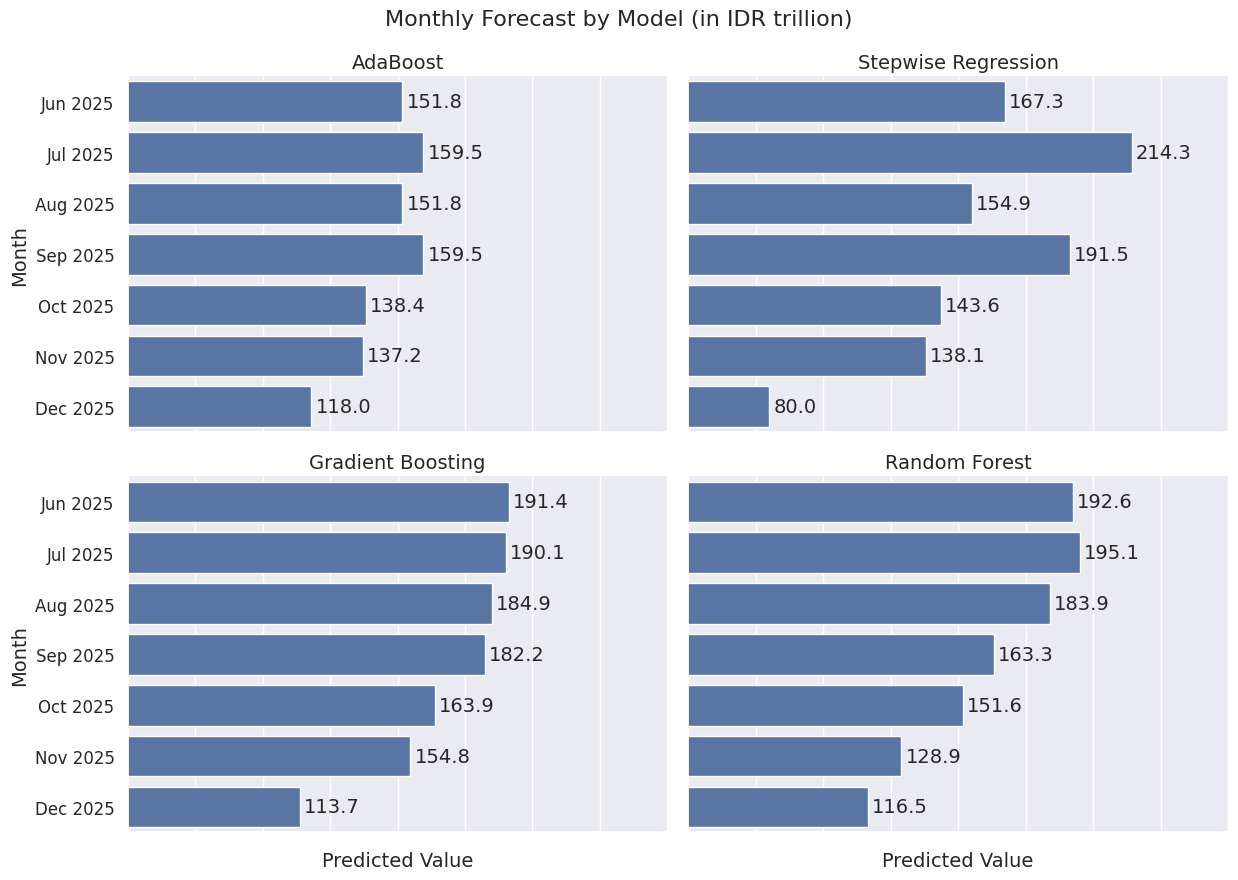

In [80]:
import matplotlib.ticker as mtick

# Create a new column in trillions (assuming values in millions)
melted_df["Predicted_Value_Trillion"] = melted_df["Predicted Value"] / 1_000

# 📊 Create facet grid
g = sns.FacetGrid(
    melted_df,
    col="Model",
    col_wrap=2,
    height=4.5,
    aspect=1.4,
    sharex=True
)

# 🌈 Plot horizontal bars with consistent color
g.map_dataframe(
    sns.barplot,
    y="Month",
    x="Predicted_Value_Trillion",
    color="#4c72b0"  # clean blue tone
)

# ✅ Format axes and add bar labels
for ax in g.axes.flat:
    ax.tick_params(axis='y', labelrotation=0)
    ax.set_ylabel("Month")
    ax.set_xlabel("Predicted Value")

    # 💬 Format x-axis
    # ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # ❌ Remove x-axis tick labels
    ax.set_xticklabels([])

    # 📏 Set x-axis limits
    ax.set_xlim(50, 250)

    # ✍️ Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', label_type='edge', padding=3)

# 🏷 Titles and layout
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle("Monthly Forecast by Model (in IDR trillion)", fontsize=16)

plt.tight_layout()
plt.show()

In [81]:
# 📊 Calculate average prediction across models for each month
monthly_avg = comparison_df[columns_to_revert].mean(axis=1)

# Combine with the original month index (if available)
monthly_avg_df = comparison_df[['Month']].copy()  # if Month is a column
monthly_avg_df['Average_Prediction'] = monthly_avg

# Format as needed
monthly_avg_df['Average_Prediction_Formatted'] = monthly_avg_df['Average_Prediction'].map('{:,.2f}'.format)

print("\n📈 Average Predicted Value per Month (Across All Models):")
print(monthly_avg_df[["Month", "Average_Prediction_Formatted"]])


📈 Average Predicted Value per Month (Across All Models):
      Month Average_Prediction_Formatted
0  Jun 2025                   175,749.74
1  Jul 2025                   189,754.80
2  Aug 2025                   168,872.83
3  Sep 2025                   174,160.43
4  Oct 2025                   149,387.94
5  Nov 2025                   139,751.85
6  Dec 2025                   107,071.42


📊 Total Incoming Bids (as of 10 June 2025)

*   SUN Auctions: Rp77,179.0 billion
*   SBSN Auctions: Rp36,892.5 billion

🧮 Total: Rp114,071.5 billion
→ Equivalent to Rp114.07 trillion

In [82]:
# 🧮 Total predictions per model
monthly_sums = comparison_df[columns_to_revert].sum()
summary_df = pd.DataFrame(monthly_sums, columns=['Total']).reset_index()
summary_df.columns = ['Model', 'Total']
summary_df['Total'] = summary_df['Total'].map('{:,.2f}'.format)

# Combine both total and average
combined_df = summary_df.copy()
combined_df['Average'] = comparison_df[columns_to_revert].mean().values
combined_df['Average'] = combined_df['Average'].map('{:,.2f}'.format)

print("\n📊 Total and Average Predicted Value by Model:")
print(combined_df)


📊 Total and Average Predicted Value by Model:
                 Model         Total     Average
0             AdaBoost  1,016,266.73  145,180.96
1  Stepwise Regression  1,089,724.54  155,674.93
2    Gradient Boosting  1,180,997.46  168,713.92
3        Random Forest  1,132,007.33  161,715.33
